## 1. Giới thiệu về Tập dữ liệu (Introduction)
Tập dữ liệu **CIFAR-10** là một bộ sưu tập các hình ảnh được sử dụng phổ biến trong các bài toán thị giác máy tính.
* Quy mô: 60.000 hình ảnh màu kích thước 32x32 pixel.
* Phân loại: 10 lớp đối tượng (máy bay, ô tô, chim, mèo, nai, chó, ếch, ngựa, tàu thủy, xe tải).
* Cấu trúc: 50.000 ảnh huấn luyện và 10.000 ảnh kiểm thử.
* Đặc điểm: Mỗi lớp có chính xác 6.000 hình ảnh, tạo nên một tập dữ liệu cân bằng hoàn hảo.

In [2]:
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128
%pip install numpy matplotlib seaborn pandas

Looking in indexes: https://download.pytorch.org/whl/cu128


## 2. Phương pháp nghiên cứu

Quy trình thực hiện được thiết kế chặt chẽ nhằm tối ưu hóa hiệu suất mô hình trên tập dữ liệu nhỏ:

1. Trích xuất và tiền xử lý dữ liệu từ file .tar.gz
2. Tái cấu trúc dữ liệu về định dạng tensor 4 chiều `(N, 32, 32, 3)`
3. Phân tích khám phá dữ liệu (EDA)
4. Tiền xử lý & Tăng cường dữ liệu (Data Augmentation)
5. Xây dựng và huấn luyện mô hình (Transfer Learning + Fine-tuning)
6. Đánh giá và so sánh kết quả

### 2.1. Các kỹ thuật nâng cao được áp dụng

**Transfer Learning**
- Sử dụng **ResNet50** và **Vision Transformer** được pre-trained trên ImageNet.
- **Freeze Backbone**: Giữ nguyên trọng số tầng convolutional, chỉ huấn luyện phần classifier.
- **Fine-tune**: Mở một phần hoặc toàn bộ backbone với learning rate nhỏ.

**Data Augmentation**
- **Standard Augmentation**: RandomFlip, RandomRotation, RandomZoom, RandomContrast.
- **CutMix**: Kỹ thuật tiên tiến (2019) cắt và dán vùng hình chữ nhật giữa 2 ảnh, đồng thời mix label theo tỷ lệ diện tích.

**Regularization**
- Label Smoothing
- Weight Decay (L2)
- Warmup + Cosine Learning Rate Decay

## 3. Triển khai Mã nguồn (Implementation)

### 3.1. Giải nén và Chuẩn bị dữ liệu

CIFAR-10 được cung cấp dưới dạng file `.tar.gz` chứa 6 batch nhị phân (5 batch train + 1 batch test). Mỗi batch có:
- `data`: mảng (10000, 3072) — ảnh đã được flatten.
- `labels`: danh sách nhãn từ 0 đến 9.

In [3]:
import os

# Source path from the file system
source_path = '/content/data/cifar-10-python.tar.gz'
dest_path = './cifar-10-python.tar.gz'

if os.path.exists(source_path):
    !cp {source_path} {dest_path}
    print(f"Copied {source_path} to current directory.")
else:
    print("File not found in /content/data/, downloading from source...")
    !wget https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz

File not found in /content/data/, downloading from source...
--2026-03-30 10:50:26--  https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
Resolving www.cs.toronto.edu (www.cs.toronto.edu)... 128.100.3.30
Connecting to www.cs.toronto.edu (www.cs.toronto.edu)|128.100.3.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 170498071 (163M) [application/x-gzip]
Saving to: ‘cifar-10-python.tar.gz’

cifar-10-python.tar 100%[===================>] 162.60M  45.4MB/s    in 4.0s    

2026-03-30 10:50:30 (40.9 MB/s) - ‘cifar-10-python.tar.gz’ saved [170498071/170498071]



In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
import tarfile
import os

# Tên file đã tải xuống từ bước 3.1
file_name = 'cifar-10-python.tar.gz'
output_dir = './output_folder'

if os.path.exists(file_name):
    with tarfile.open(file_name, 'r:gz') as tar:
        tar.extractall(path=output_dir)
        print(f"Đã giải nén thành công vào {output_dir}")
else:
    print("Lỗi: Không tìm thấy file cifar-10-python.tar.gz. Hãy chạy lại cell tải dữ liệu ở mục 3.1.")

/tmp/ipykernel_4629/2058467999.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=output_dir)


Đã giải nén thành công vào ./output_folder


### 3.2. Nạp và Tái cấu trúc Dữ liệu

Dữ liệu gốc là vector phẳng 3072 chiều. Ta thực hiện reshape và transpose để chuyển về định dạng tensor phù hợp với Keras/TensorFlow:

```python
(50000, 3072) → (50000, 3, 32, 32) → (50000, 32, 32, 3)

In [5]:
import pickle
import numpy as np
import os

def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

In [6]:
import os
import numpy as np

def load_cifar10_data(data_dir):
    train_data = []
    train_labels = []

    # Load đủ 5 training batches
    for i in range(1, 6):
        batch_path = os.path.join(data_dir, f'data_batch_{i}')
        batch = unpickle(batch_path)
        train_data.append(batch[b'data'])
        train_labels.extend(batch[b'labels'])

    X_train = np.concatenate(train_data)
    y_train = np.array(train_labels)

    # Load test batch
    test_batch = unpickle(os.path.join(data_dir, 'test_batch'))
    X_test = test_batch[b'data']
    y_test = np.array(test_batch[b'labels'])

    return X_train, y_train, X_test, y_test

# Đường dẫn chuẩn sau khi giải nén file gốc
data_folder = './output_folder/cifar-10-batches-py'

if os.path.exists(data_folder):
    X_train, y_train, X_test, y_test = load_cifar10_data(data_folder)
    print(f"Nạp dữ liệu Numpy thành công. X_train shape: {X_train.shape}")
else:
    print(f"Lỗi: Không tìm thấy thư mục {data_folder}. Hãy kiểm tra lại bước giải nén.")

Nạp dữ liệu Numpy thành công. X_train shape: (50000, 3072)


In [7]:
import torch

def reshape_cifar_torch(data):
    # PyTorch sử dụng định dạng (N, C, H, W)
    # 1. Reshape từ vector phẳng (3072) -> (3, 32, 32)
    data = data.reshape(-1, 3, 32, 32)
    # Chuyển thành Torch Tensor và chuẩn hóa về [0, 1]
    return torch.from_numpy(data).float() / 255.0

X_train = reshape_cifar_torch(X_train)
X_test = reshape_cifar_torch(X_test)
y_train = torch.tensor(y_train).long()
y_test = torch.tensor(y_test).long()

print(f"Final Torch Shape: {X_train.shape}") # (50000, 3, 32, 32)

Final Torch Shape: torch.Size([50000, 3, 32, 32])


### 3.3. Phân tích Dữ liệu Khám phá (EDA)

Kiểm tra sự cân bằng của các lớp và đặc điểm thống kê của pixel.

#### 3.3.1. Kiểm tra sự phân bổ các lớp

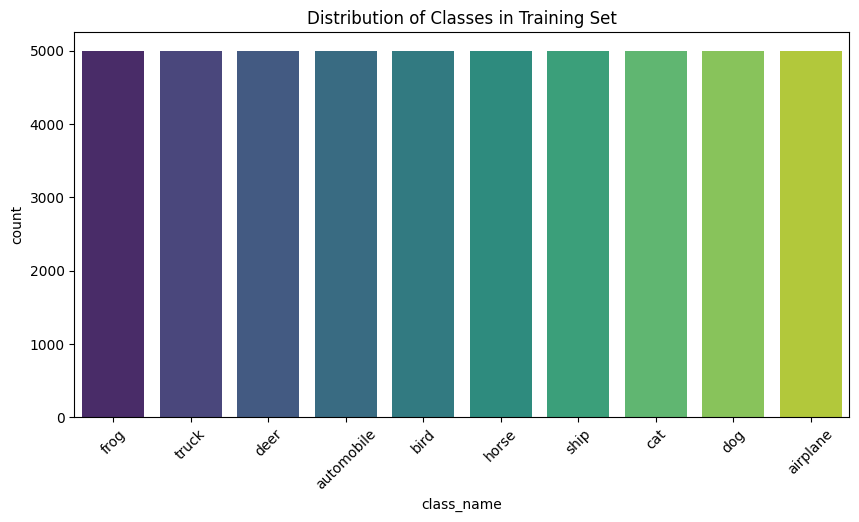

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

label_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Create a DataFrame for easy plotting
df_train = pd.DataFrame(y_train, columns=['label'])
df_train['class_name'] = df_train['label'].apply(lambda x: label_names[x])

plt.figure(figsize=(10, 5))
sns.countplot(data=df_train, x='class_name', hue='class_name', palette='viridis', legend=False)
plt.title('Distribution of Classes in Training Set')
plt.xticks(rotation=45)
plt.show()

**Nhận xét từ EDA**:
- Mỗi lớp có đúng 5000 ảnh trong tập train → dataset **hoàn toàn cân bằng**.
- Không cần xử lý class imbalance.

#### 3.3.2. Kiểm tra tính toàn vẹn trực quan

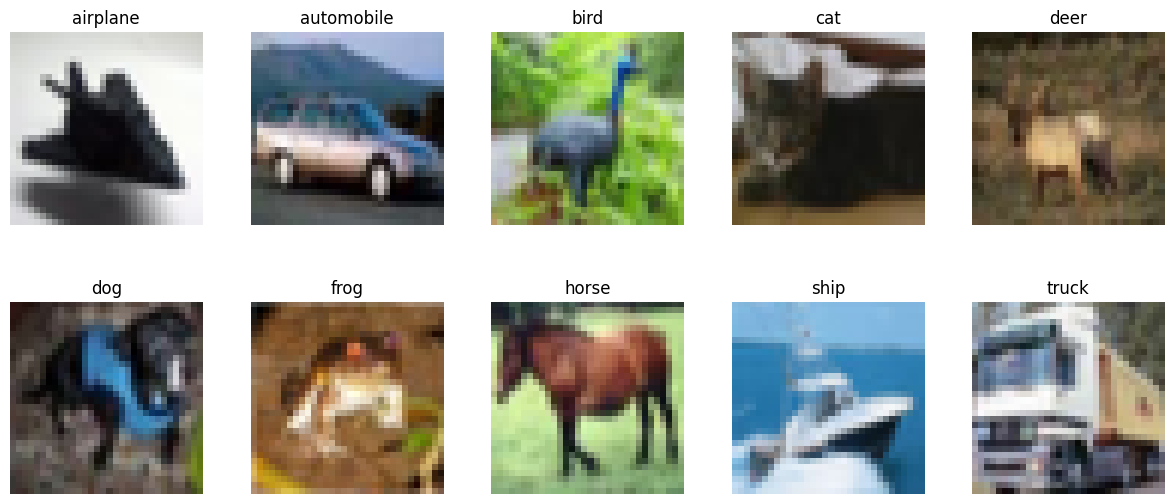

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(10):
    # Tìm ảnh đầu tiên của mỗi lớp
    idx = torch.where(y_train == i)[0][0]
    # Chuyển từ (C, H, W) -> (H, W, C) để Matplotlib có thể hiển thị
    img = X_train[idx].permute(1, 2, 0).numpy()

    axes[i].imshow(img)
    axes[i].set_title(label_names[i])
    axes[i].axis('off')

plt.subplots_adjust(hspace=0.4)
plt.show()

#### 3.3.3. Phân tích phân phối pixel theo từng kênh màu (RGB)

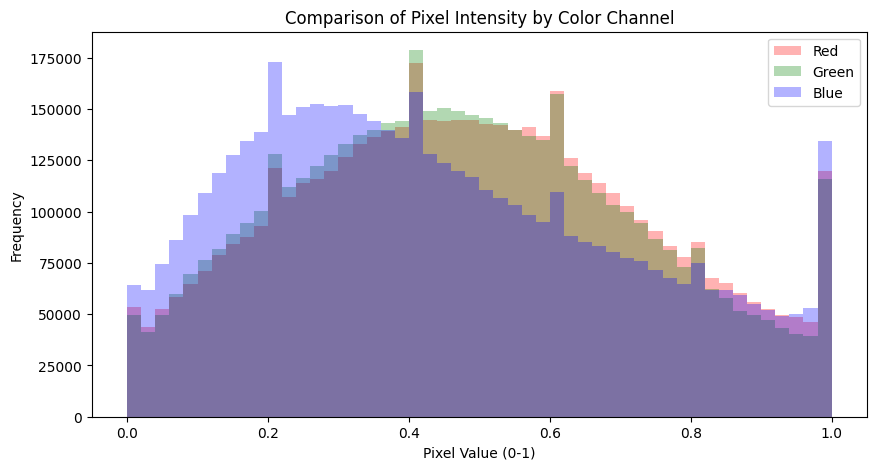

Red Channel - Mean: 0.4899, Std: 0.2464
Green Channel - Mean: 0.4799, Std: 0.2431
Blue Channel - Mean: 0.4445, Std: 0.2616


In [10]:
# Sample for speed
sample_idx = np.random.choice(len(X_train), 5000)
sample_data = X_train[sample_idx] # Shape (5000, 3, 32, 32)

plt.figure(figsize=(10, 5))
# Plot Red, Green, and Blue distributions
# PyTorch: [N, C, H, W] -> C=0: Red, C=1: Green, C=2: Blue
plt.hist(sample_data[:, 0, :, :].flatten().numpy(), bins=50, color='red', alpha=0.3, label='Red')
plt.hist(sample_data[:, 1, :, :].flatten().numpy(), bins=50, color='green', alpha=0.3, label='Green')
plt.hist(sample_data[:, 2, :, :].flatten().numpy(), bins=50, color='blue', alpha=0.3, label='Blue')

plt.legend()
plt.title("Comparison of Pixel Intensity by Color Channel")
plt.xlabel("Pixel Value (0-1)")
plt.ylabel("Frequency")
plt.show()

# Calculate mean and std for each channel (dim 0, 2, 3 are N, H, W)
mean = sample_data.mean(dim=(0, 2, 3))
std = sample_data.std(dim=(0, 2, 3))

# Print specific stats for your report
for i, color in enumerate(['Red', 'Green', 'Blue']):
    print(f"{color} Channel - Mean: {mean[i]:.4f}, Std: {std[i]:.4f}")

### 3.4. Tiền xử lý dữ liệu (Data Preprocessing)
**Các bước chính**:
- Chuẩn hóa pixel về khoảng `[0, 1]`
- One-hot encoding nhãn
- Phân tách tập validation (80/20)
- Data Augmentation (Standard)

In [45]:
from torch.utils.data import DataLoader, TensorDataset, random_split

X_train_norm = X_train.float() / 255.0 if X_train.max() > 1.0 else X_train.float()
X_test_norm = X_test.float() / 255.0 if X_test.max() > 1.0 else X_test.float()
# 1. Tạo Dataset
full_train_dataset = TensorDataset(X_train_norm, y_train)
test_dataset = TensorDataset(X_test_norm, y_test)

# 2. Phân tách tập Validation (80/20)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Preprocessing Complete (PyTorch).")
print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}, Test samples: {len(test_dataset)}")

Preprocessing Complete (PyTorch).
Train samples: 40000, Val samples: 10000, Test samples: 10000


In [46]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Định nghĩa các bước Augmentation (Xoay, Cắt, Normalize Mean/Std)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation(15),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Đưa về dải quanh số 0
])

test_transform = transforms.Compose([
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Lớp bọc để áp dụng Transform vào TensorDataset
class AugmentedDataset(Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.dataset[index]
        if self.transform: x = self.transform(x)
        return x, y
    def __len__(self): return len(self.dataset)

# KHỞI TẠO DATALOADER (Thấy rõ Loader ở đây)
train_loader = DataLoader(AugmentedDataset(train_dataset, train_transform), batch_size=64, shuffle=True)
val_loader = DataLoader(AugmentedDataset(val_dataset, test_transform), batch_size=64, shuffle=False)
test_loader = DataLoader(AugmentedDataset(test_dataset, test_transform), batch_size=64, shuffle=False)

print("✅ Đã chuẩn hóa 0-1, thiết lập Augmentation và khởi tạo DataLoader thành công!")

✅ Đã chuẩn hóa 0-1, thiết lập Augmentation và khởi tạo DataLoader thành công!


Vì hình ảnh CIFAR-10 có độ phân giải thấp, mô hình rất dễ bị "overfitting". Vì vậy, nhóm sử dụng `ImageDataGenerator` để thực hiện các phép biến đổi ngẫu nhiên ngay trong quá trình huấn luyện.

**Kiểm tra trực quan sau tiền xử lý (Final Sanity Check)**

Bước này đảm bảo rằng sau tất cả các bước tải, tái cấu trúc, chuẩn hóa và mã hóa, dữ liệu vẫn giữ được ý nghĩa logic.

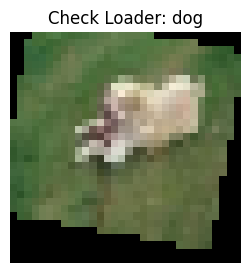

Pixel Range in Loader: [-1.00, 0.96]
Image Shape: torch.Size([3, 32, 32])


In [47]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Lấy 1 batch dữ liệu từ train_loader
data_iter = iter(train_loader)
images, labels = next(data_iter)

# 2. Chọn ảnh đầu tiên trong batch để hiển thị
img = images[0]
label = labels[0].item()

# 3. Vì chúng ta đã Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
# nên ảnh hiện tại đang ở dải [-1, 1]. Cần đưa về [0, 1] để plt.imshow hiển thị đúng màu.
img_display = img * 0.5 + 0.5  # Công thức ngược của Normalize
img_display = img_display.permute(1, 2, 0).numpy() # Chuyển từ (C, H, W) sang (H, W, C)

# 4. Hiển thị
label_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(5, 3))
plt.imshow(np.clip(img_display, 0, 1)) # Clip để đảm bảo không bị lỗi dải màu
plt.title(f"Check Loader: {label_names[label]}")
plt.axis('off')
plt.show()

# 5. Kiểm tra giá trị Pixel thực tế mô hình nhận được (đã chuẩn hóa quanh 0)
print(f"Pixel Range in Loader: [{img.min():.2f}, {img.max():.2f}]")
print(f"Image Shape: {img.shape}") # Nên là [3, 32, 32]

In [48]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import copy

# Hàm helper để tạo N lớp giống hệt nhau
def clones(module, N):
    return nn.ModuleList([copy.deepcopy(module) for _ in range(N)])

In [15]:
class LayerNorm(nn.Module):
    def __init__(self, features, eps=1e-6):
        super(LayerNorm, self).__init__()
        # features tương ứng với d_model
        self.a = nn.Parameter(torch.ones(features))
        self.b = nn.Parameter(torch.zeros(features))
        self.eps = eps

    def forward(self, x):
        mean = x.mean(-1, keepdim=True)
        std = x.std(-1, keepdim=True)
        return self.a * (x - mean) / (std + self.eps) + self.b

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_k = d_model // n_heads
        self.h = n_heads

        # Các phép chiếu tuyến tính (Linear Projections)
        self.w_queries = nn.Linear(d_model, d_model)
        self.w_keys = nn.Linear(d_model, d_model)
        self.w_values = nn.Linear(d_model, d_model)
        self.fc_out = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)

        # 1. Project và Reshape: (batch, seq, d_model) -> (batch, heads, seq, d_k)
        Q = self.w_queries(query).view(batch_size, -1, self.h, self.d_k).transpose(1, 2)
        K = self.w_keys(key).view(batch_size, -1, self.h, self.d_k).transpose(1, 2)
        V = self.w_values(value).view(batch_size, -1, self.h, self.d_k).transpose(1, 2)

        # 2. Tính Scores bằng EINSUM (Yêu cầu bài tập)
        # b: batch, h: heads, q: query_len, k: key_len, d: d_k
        scores = torch.einsum('bhqd, bhkd -> bhqk', Q, K) / math.sqrt(self.d_k)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        p_attn = torch.softmax(scores, dim=-1)
        p_attn = self.dropout(p_attn)

        # 3. Tính Context Vector bằng EINSUM
        # v: value_len
        out = torch.einsum('bhqk, bhkv -> bhqv', p_attn, V)

        # 4. Ghép các heads lại và Linear cuối
        out = out.transpose(1, 2).contiguous().view(batch_size, -1, self.h * self.d_k)
        return self.fc_out(out)

In [16]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.w_2(self.dropout(F.relu(self.w_1(x))))

class SublayerConnection(nn.Module):
    """Cơ chế Residual + LayerNorm (Pre-Norm)"""
    def __init__(self, size, dropout):
        super().__init__()
        self.norm = LayerNorm(size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, sublayer):
        # Pre-Norm: Norm trước khi tính toán
        return x + self.dropout(sublayer(self.norm(x)))

class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.feed_forward = FeedForward(d_model, d_ff, dropout)
        self.sublayers = clones(SublayerConnection(d_model, dropout), 2)

    def forward(self, x, mask=None):
        x = self.sublayers[0](x, lambda x: self.self_attn(x, x, x, mask))
        return self.sublayers[1](x, self.feed_forward)

In [18]:
class TransformerEncoder(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, n_layers, dropout=0.1):
        super().__init__()
        self.layers = clones(EncoderLayer(d_model, n_heads, d_ff, dropout), n_layers)
        self.norm = LayerNorm(d_model)
        self.reset_parameters()

    def reset_parameters(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, x, mask=None):
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x)

In [19]:
import torch
import torch.nn as nn

class ViTScratch(nn.Module):
    def __init__(
        self,
        img_size=32,      # Kích thước ảnh CIFAR-10
        patch_size=4,     # Kích thước mỗi patch (4x4)
        num_classes=10,   # 10 lớp đối tượng
        dim=128,      # Số chiều vector (dim)
        depth=6,       # Số tầng Transformer
        num_heads=8,        # Số đầu Attention
        mlp_dim=256,         # Số chiều tầng ẩn FeedForward
        dropout=0.1,
    ):
        super().__init__()
        assert img_size % patch_size == 0
        num_patches = (img_size // patch_size) ** 2

        # 1. Patch Embedding: (B, 3, 32, 32) -> (B, d_model, 8, 8)
        self.patch_embed = nn.Conv2d(
            in_channels=3,
            out_channels=dim,
            kernel_size=patch_size,
            stride=patch_size
        )

        # 2. CLS Token và Position Embedding
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, dim))
        self.dropout = nn.Dropout(dropout)

        # 3. Transformer Encoder (Sử dụng class của bạn)
        self.encoder = TransformerEncoder(
            d_model=dim,      # Truyền dim vào d_model của encoder
            n_heads=num_heads,
            d_ff=mlp_dim,     # Truyền mlp_dim vào d_ff
            n_layers=depth,   # Truyền depth vào n_layers
            dropout=dropout
        )

        # 4. Classification Head
        self.head = nn.Sequential(
            LayerNorm(dim), # Sử dụng LayerNorm tự viết của bạn
            nn.Linear(dim, num_classes)
        )

    def forward(self, x):
        bsz = x.size(0)

        # Bước 1: Trải phẳng các patch thành chuỗi (Flattening)
        # (B, d_model, 8, 8) -> (B, d_model, 64) -> (B, 64, d_model)
        x = self.patch_embed(x).flatten(2).transpose(1, 2)

        # Bước 2: Thêm CLS Token vào đầu chuỗi
        cls_tokens = self.cls_token.expand(bsz, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1) # (B, 65, d_model)

        # Bước 3: Thêm thông tin vị trí và Dropout
        x = x + self.pos_embed
        x = self.dropout(x)

        # Bước 4: Đi qua các tầng Transformer Encoder
        x = self.encoder(x) # Đầu ra: (B, 65, d_model)

        # Bước 5: Lấy vector đại diện của CLS Token (vị trí đầu tiên) để phân loại
        cls_token_final = x[:, 0]

        return self.head(cls_token_final)

In [20]:
import torch
import torch.nn as nn

class ViTBuiltin(nn.Module):
    def __init__(
        self,
        img_size=32,
        patch_size=4,
        num_classes=10,
        dim=128,
        depth=6,
        num_heads=8,
        mlp_dim=256,
        dropout=0.1,
    ):
        super().__init__()
        assert img_size % patch_size == 0
        num_patches = (img_size // patch_size) ** 2

        # 1. Patch Embedding (Giữ giống bản Scratch để so sánh công bằng)
        self.patch_embed = nn.Conv2d(3, dim, kernel_size=patch_size, stride=patch_size)

        # 2. Learnable Tokens
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, dim))
        self.dropout = nn.Dropout(dropout)

        # 3. Sử dụng Transformer Encoder của PyTorch (Built-in)
        # Lưu ý: norm_first=True tương ứng với Pre-Norm (giống bản Scratch của bạn)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim,
            nhead=num_heads,
            dim_feedforward=mlp_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=depth,
            enable_nested_tensor=False)

        # 4. Classification Head
        self.head = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, num_classes)
        )

    def forward(self, x):
        bsz = x.size(0)

        # Patching & Embedding
        x = self.patch_embed(x)
        x = x.flatten(2).transpose(1, 2)

        # Add CLS Token
        cls = self.cls_token.expand(bsz, -1, -1)
        x = torch.cat([cls, x], dim=1)

        # Add Positional Info
        x = x + self.pos_embed
        x = self.dropout(x)

        # Built-in Transformer Forward
        x = self.encoder(x)

        # Classification dựa trên CLS Token
        x = x[:, 0]
        return self.head(x)

In [21]:
# Kiểm tra nhanh
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_s = ViTScratch().to(device)
model_b = ViTBuiltin().to(device)

dummy_input = torch.randn(4, 3, 32, 32).to(device)

print(f"Scratch output: {model_s(dummy_input).shape}") # Mong đợi: [2, 10]
print(f"Built-in output: {model_b(dummy_input).shape}") # Mong đợi: [2, 10]

Scratch output: torch.Size([4, 10])
Built-in output: torch.Size([4, 10])


In [22]:
# Cấu hình tham số giống ViT-Base
model = TransformerEncoder(d_model=768, n_heads=12, d_ff=3072, n_layers=6)

# Giả lập input (Batch=1, Seq=197, Dim=768) - 197 = 196 patches + 1 cls token
x = torch.randn(1, 197, 768)

output = model(x)
print(f"Kích thước đầu ra: {output.shape}") # Kỳ vọng: [1, 197, 768]

Kích thước đầu ra: torch.Size([1, 197, 768])


/tmp/ipykernel_4629/2097036152.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_params, x="Kiến trúc", y="Tham số (Triệu)", palette="magma")


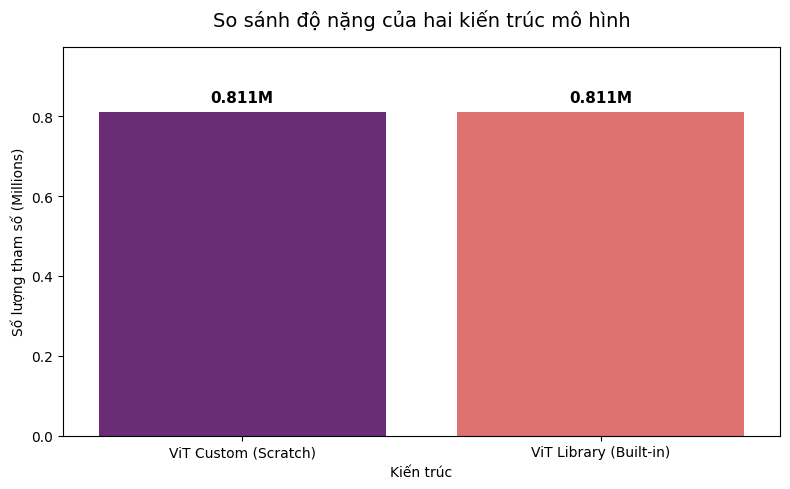

In [49]:
def count_params(model):
    # Đếm tổng số lượng tham số có thể train
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Khởi tạo model tạm để đếm
v_scratch = ViTScratch()
v_builtin = ViTBuiltin()

# Tạo DataFrame so sánh
param_data = {
    "Kiến trúc": ["ViT Custom (Scratch)", "ViT Library (Built-in)"],
    "Tham số (Triệu)": [count_params(v_scratch)/1e6, count_params(v_builtin)/1e6],
    "Trạng thái": ["Manual Implementation", "PyTorch Optimized"]
}
df_params = pd.DataFrame(param_data)

# Vẽ biểu đồ so sánh tham số
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=df_params, x="Kiến trúc", y="Tham số (Triệu)", palette="magma")
plt.title("So sánh độ nặng của hai kiến trúc mô hình", fontsize=14, pad=15)
plt.ylabel("Số lượng tham số (Millions)")
plt.ylim(0, df_params["Tham số (Triệu)"].max() * 1.2) # Tạo khoảng trống phía trên cho nhãn

# Ghi số cụ thể lên đầu cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}M', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

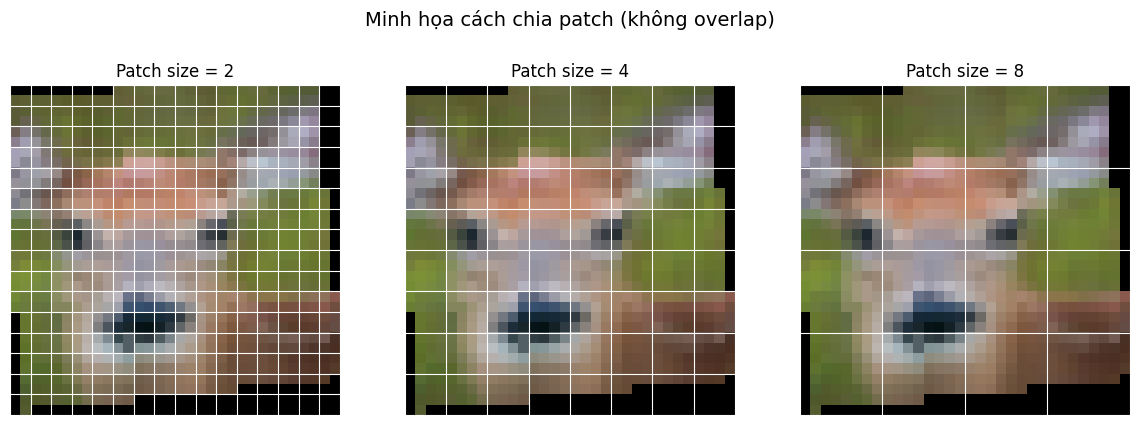

In [52]:
# 1. Lấy mẫu và xử lý ảnh bên ngoài hàm để giữ màu đậm
sample_images, _ = next(iter(train_loader))
sample_img = sample_images[0].detach().cpu()

sample_img = sample_img * 0.5 + 0.5
sample_img = sample_img.clamp(0, 1)

def draw_patch_grid(ax, img, patch_size, title):
    np_img = img.permute(1, 2, 0).numpy()

    # Thêm interpolation='none' để tránh bị mờ khi hiển thị
    ax.imshow(np_img, interpolation='none')

    h, w = np_img.shape[:2]
    # Vẽ lưới trắng sắc nét tại ranh giới pixel
    for y in range(0, h + 1, patch_size):
        ax.axhline(y=y - 0.5, color="white", linewidth=0.8)
    for x in range(0, w + 1, patch_size):
        ax.axvline(x=x - 0.5, color="white", linewidth=0.8)

    ax.set_title(title)
    ax.axis("off")

# 2. Hiển thị
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
draw_patch_grid(axes[0], sample_img, 2, "Patch size = 2")
draw_patch_grid(axes[1], sample_img, 4, "Patch size = 4")
draw_patch_grid(axes[2], sample_img, 8, "Patch size = 8")

plt.suptitle("Minh họa cách chia patch (không overlap)", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

In [53]:
patch_options = [2, 4, 8, 16]
img_res = 32

token_analysis = pd.DataFrame({
    "Kích thước Patch": [f"{p}x{p}" for p in patch_options],
    "Số lượng Token (N)": [(img_res // p)**2 for p in patch_options],
    "Độ chi tiết": ["Rất cao (Nặng)", "Cân bằng (Khuyên dùng)", "Thấp", "Rất thấp (Mất thông tin)"],
    "Độ phức tạp Self-Attention": [f"O({((img_res//p)**2)**2})" for p in patch_options]
})

print("--- PHÂN TÍCH CHIẾN LƯỢC CHIA PATCH ---")
display(token_analysis)

--- PHÂN TÍCH CHIẾN LƯỢC CHIA PATCH ---


,Kích thước Patch,Số lượng Token (N),Độ chi tiết,Độ phức tạp Self-Attention
0,2x2,256,Rất cao (Nặng),O(65536)
1,4x4,64,Cân bằng (Khuyên dùng),O(4096)
2,8x8,16,Thấp,O(256)
3,16x16,4,Rất thấp (Mất thông tin),O(16)


In [54]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import copy
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# Thiết lập thiết bị chạy (Ưu tiên GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {device}")

Đang sử dụng thiết bị: cuda


In [59]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()
    all_preds, all_labels = [], []
    running_loss = 0.0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)

        if criterion is not None:
            running_loss += criterion(logits, labels).item()

        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    # Tính toán đầy đủ các chỉ số
    return {
        "loss": running_loss / len(loader) if criterion else None,
        "acc": (all_preds == all_labels).mean(),
        "precision": precision_score(all_labels, all_preds, average="macro", zero_division=0),
        "recall": recall_score(all_labels, all_preds, average="macro", zero_division=0),
        "f1": f1_score(all_labels, all_preds, average="macro"),
        "cm": confusion_matrix(all_labels, all_preds)
    }

def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    # Thêm Scheduler để kết quả tốt hơn (như đã thảo luận)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}
    best_acc = -1.0 # Đổi sang theo dõi Accuracy
    best_state = None

    start = time.perf_counter()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        scheduler.step() # Cập nhật LR

        train_loss = running_loss / len(train_loader)
        val_m = evaluate(model, val_loader, criterion=criterion)

        # Lưu lịch sử
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_m["loss"])
        history["val_acc"].append(val_m["acc"])
        history["val_f1"].append(val_m["f1"])

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} | val_loss={val_m['loss']:.4f} | "
            f"val_acc={val_m['acc']:.4f} | val_f1={val_m['f1']:.4f}"
        )

        # CẬP NHẬT: Lưu model có Accuracy tốt nhất
        if val_m["acc"] > best_acc:
            best_acc = val_m["acc"]
            best_state = copy.deepcopy(model.state_dict())

    if best_state:
        model.load_state_dict(best_state)

    return model, history, time.perf_counter() - start

In [56]:
def run_benchmark(models_dict, train_loader, val_loader, test_loader, epochs=10, lr=1e-4):
    results = []
    histories = {}
    conf_mats = {}

    for name, model in models_dict.items():
        print(f"\n>>> Đang thực hiện kiến trúc: {name}")
        best_model, history, duration = train_model(model, train_loader, val_loader, epochs, lr)

        # Test cuối cùng trên tập Test
        test_m = evaluate(best_model, test_loader, criterion=nn.CrossEntropyLoss())

        results.append({
            "Model": name,
            "Accuracy": test_m["acc"],
            "F1-score": test_m["f1"],
            "Precision": test_m["precision"],
            "Recall": test_m["recall"],
            "Time (s)": duration
        })
        histories[name] = history
        conf_mats[name] = test_m["cm"]

    return pd.DataFrame(results), histories, conf_mats

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_comparison(histories, conf_mats, class_names):
    epochs = range(1, len(next(iter(histories.values()))["train_loss"]) + 1)
    plt.rcParams.update({'font.size': 14})
    # --- 1. Vẽ biểu đồ so sánh Loss, Acc, F1 ---
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Dùng flatten() để biến ma trận [[ax1, ax2], [ax3, ax4]] thành [ax1, ax2, ax3, ax4]
    ax1, ax2, ax3, ax4 = axes.flatten()
    colors = ['#1f77b4', '#ff7f0e'] # Xanh cho Built-in, Cam cho Scratch
    markers = ['o', 's']

    for i, (name, hist) in enumerate(histories.items()):
        # Vẽ Train Loss
        ax1.plot(epochs, hist["train_loss"], marker=markers[i], color=colors[i], label=f'{name}')
        ax1.set_title('Comparison: Training Loss')
        ax1.legend()

        # Vẽ Val Loss
        ax2.plot(epochs, hist["train_loss"], marker=markers[i], color=colors[i], label=f'{name}')
        ax2.set_title('Comparison: Validation Loss')
        ax2.legend()

        # Vẽ Accuracy
        ax3.plot(epochs, hist["val_acc"], marker=markers[i], color=colors[i], label=f'{name}')
        ax3.set_title('Comparison: Validation Accuracy')
        ax3.legend()

        # Vẽ F1-Score
        ax4.plot(epochs, hist["val_f1"], marker=markers[i], color=colors[i], label=f'{name}')
        ax4.set_title('Comparison: F1-Score')
        ax4.legend()

    for ax in [ax1, ax2, ax3, ax4]:
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.set_xlabel('Epochs')
        ax.legend()

    plt.tight_layout()
    plt.show()

    # --- 2. Vẽ Confusion Matrix (Riêng biệt từng con) ---
    for name, cm in conf_mats.items():
        # 1. Thu nhỏ figsize xuống (6, 5) hoặc (7, 5) để không bị choán chỗ
        plt.figure(figsize=(5, 4))

        # 2. Dùng annot_kws để thu nhỏ font chữ của các con số bên trong ô
        # 3. Thêm linewidths để các ô tách biệt rõ ràng, nhìn sang hơn
        # 4. cbar_kws={"shrink": .8} để thu nhỏ thanh màu bên cạnh
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names,
                    annot_kws={"size": 9},
                    linewidths=.5,
                    cbar_kws={"shrink": .8})

        plt.title(f'Confusion Matrix: {name}', fontsize=12, pad=10)
        plt.ylabel('True Label', fontsize=10)
        plt.xlabel('Predicted Label', fontsize=10)

        # 5. Xoay nhãn trục X để không bị dính chữ nếu tên lớp dài
        plt.xticks(rotation=45, ha='right', fontsize=9)
        plt.yticks(fontsize=9)
        plt.show()


In [60]:
# --- 1. CẤU HÌNH SIÊU THAM SỐ (CONFIG) ---
PART3_EPOCHS = 20      # Số epoch huấn luyện
LEARNING_RATE = 1e-3   # Tốc độ học
PATCH_SIZE = 4         # Kích thước patch (tối ưu cho CIFAR-10)
DIM = 128              # Số chiều vector embedding
NUM_HEADS = 8          # Số đầu Attention

# --- 2. KHỞI TẠO CÁC MÔ HÌNH ---
# Truyền trực tiếp các tham số cấu hình vào mô hình
part3_models = {
    "ViT_builtin": ViTBuiltin(
        patch_size=PATCH_SIZE,
        dim=DIM,
        num_heads=NUM_HEADS
    ).to(device),

    "ViT_scratch": ViTScratch(
        patch_size=PATCH_SIZE,
        dim=DIM,
        num_heads=NUM_HEADS
    ).to(device),
}

# --- 3. KÍCH HOẠT BENCHMARK ---
print(f"🚀 Bắt đầu Benchmark với Patch Size = {PATCH_SIZE}...")
print(f"Thiết bị đang sử dụng: {device}")

# Thực hiện chạy toàn bộ quy trình: Train -> Evaluate -> Test
part3_df, part3_histories, part3_conf_mats = run_benchmark(
    part3_models,
    train_loader,
    val_loader,
    test_loader,
    epochs=PART3_EPOCHS,
    lr=LEARNING_RATE,
)

# --- 4. HIỂN THỊ KẾT QUẢ CUỐI CÙNG ---
print("\n" + "="*40)
print("   KẾT QUẢ SO SÁNH VIT TỰ CODE VS THƯ VIỆN")
print("="*40)
display(part3_df)

🚀 Bắt đầu Benchmark với Patch Size = 4...
Thiết bị đang sử dụng: cuda

>>> Đang thực hiện kiến trúc: ViT_builtin
Epoch 01/20 | train_loss=1.9199 | val_loss=1.6587 | val_acc=0.3896 | val_f1=0.3619
Epoch 02/20 | train_loss=1.6826 | val_loss=1.5593 | val_acc=0.4435 | val_f1=0.4357
Epoch 03/20 | train_loss=1.5935 | val_loss=1.4636 | val_acc=0.4746 | val_f1=0.4611
Epoch 04/20 | train_loss=1.5358 | val_loss=1.4126 | val_acc=0.4887 | val_f1=0.4787
Epoch 05/20 | train_loss=1.4841 | val_loss=1.3704 | val_acc=0.5124 | val_f1=0.5063
Epoch 06/20 | train_loss=1.4381 | val_loss=1.3185 | val_acc=0.5226 | val_f1=0.5077
Epoch 07/20 | train_loss=1.3987 | val_loss=1.2877 | val_acc=0.5381 | val_f1=0.5355
Epoch 08/20 | train_loss=1.3592 | val_loss=1.2293 | val_acc=0.5587 | val_f1=0.5571
Epoch 09/20 | train_loss=1.3193 | val_loss=1.2384 | val_acc=0.5574 | val_f1=0.5551
Epoch 10/20 | train_loss=1.2777 | val_loss=1.1701 | val_acc=0.5823 | val_f1=0.5785
Epoch 11/20 | train_loss=1.2438 | val_loss=1.1558 | val_a

,Model,Accuracy,F1-score,Precision,Recall,Time (s)
0,ViT_builtin,0.6288,0.625424,0.624948,0.6288,951.753296
1,ViT_scratch,0.6069,0.603077,0.603210,0.6069,968.422225


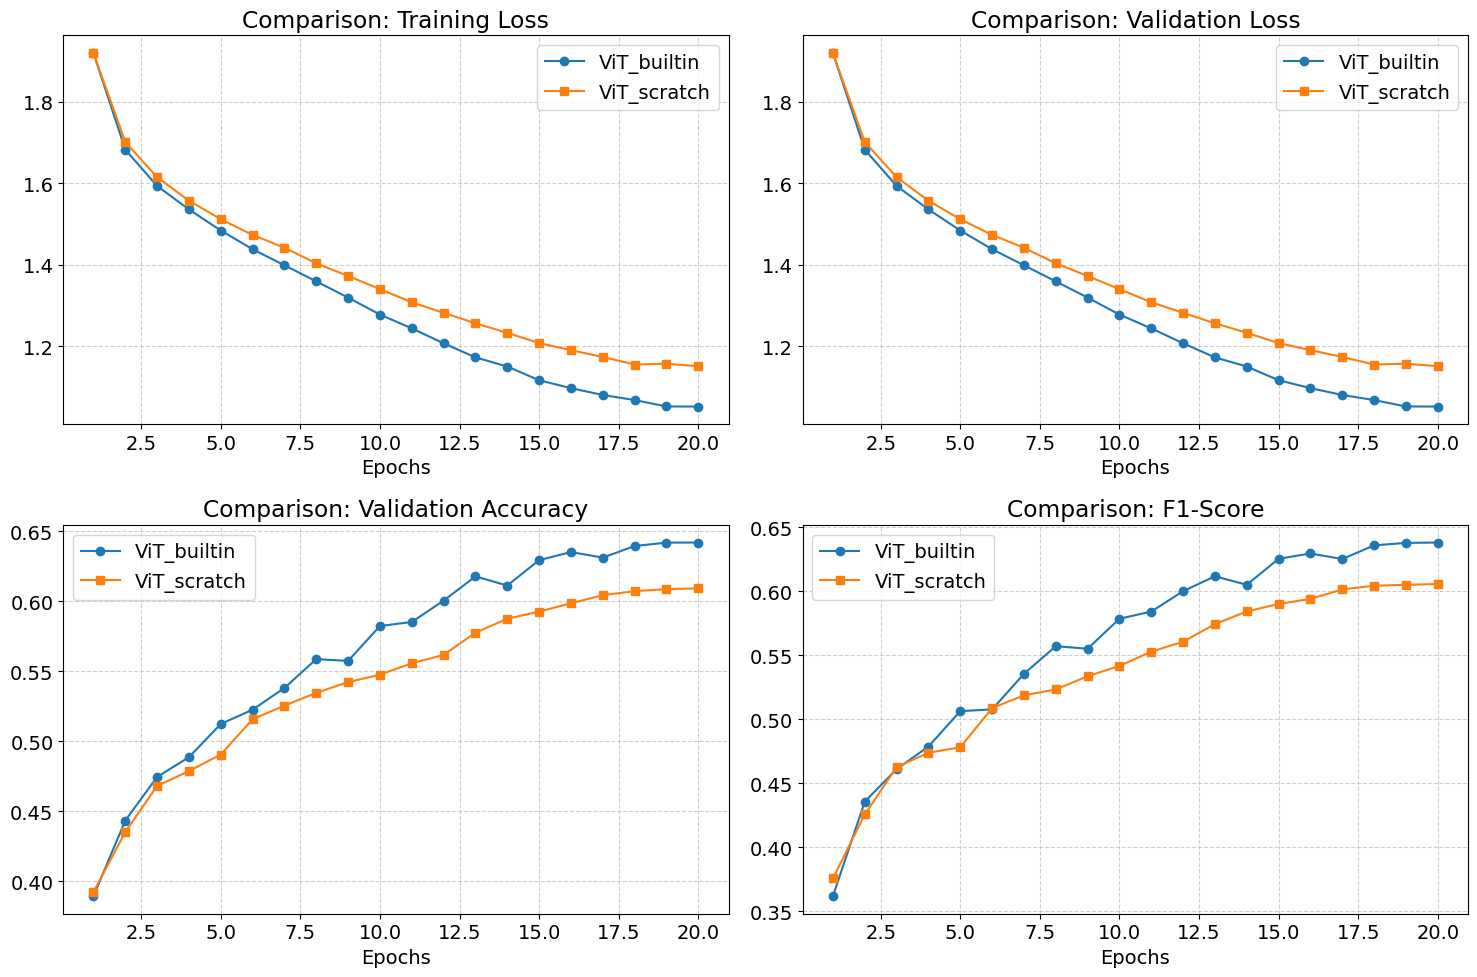

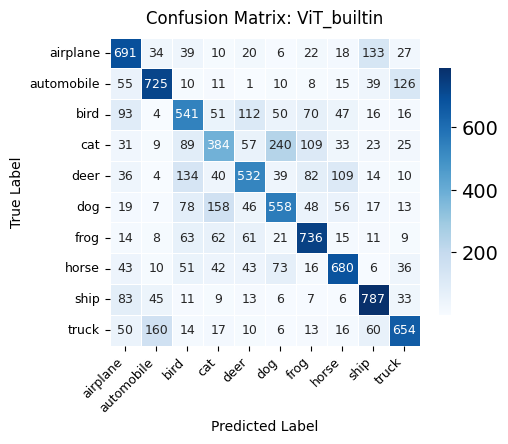

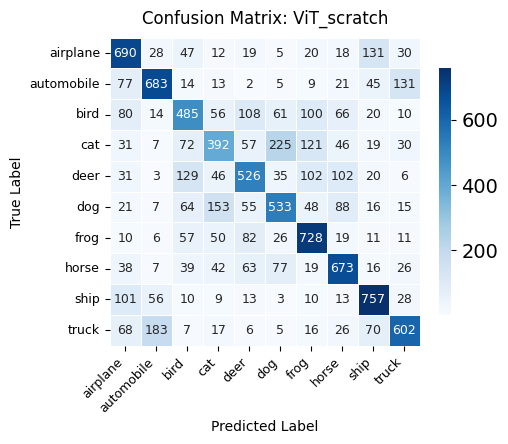

In [87]:
# Danh sách nhãn CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# GỌI LỆNH CHẠY PLOT
plot_comparison(part3_histories, part3_conf_mats, class_names)

In [89]:
# Sắp xếp để lấy con tốt nhất lên đầu
df_sorted = part3_df.sort_values(by='Accuracy', ascending=False)
best_model = df_sorted.iloc[0]['Model']

print(f"{'='*30}")
print(f"🏆 KẾT QUẢ SO SÁNH CUỐI CÙNG")
print(f"{'='*30}")
display(df_sorted) # Hiển thị bảng đẹp trong Jupyter/Colab

print(f"\n📢 Nhận xét tổng quan:")
print(f"- Mô hình tối ưu nhất: {best_model}")
print(f"- Chênh lệch Accuracy: {abs(part3_df.iloc[0]['Accuracy'] - part3_df.iloc[1]['Accuracy']):.2%}")

🏆 KẾT QUẢ SO SÁNH CUỐI CÙNG


,Model,Accuracy,F1-score,Precision,Recall,Time (s)
0,ViT_builtin,0.6288,0.625424,0.624948,0.6288,951.753296
1,ViT_scratch,0.6069,0.603077,0.603210,0.6069,968.422225



📢 Nhận xét tổng quan:
- Mô hình tối ưu nhất: ViT_builtin
- Chênh lệch Accuracy: 2.19%
